# DRL Assignment 1 — Part 1 (MAB)
## Adaptive Treatment Recommendation System using Multi-Armed Bandit Learning

**Course:** Deep Reinforcement Learning &nbsp;|&nbsp; **Group:** 37

We model the treatment selection problem as a Multi-Armed Bandit where each medicine is one arm.
Since we don't know which medicine works best upfront, the bandit has to learn from patient outcomes.
Our dataset has 1000 patients and we test different strategies to see which collects the most utility.

**Tasks:**
1. Dataset design
2. Immediate Exploitation Strategy
3. Controlled Clinical Trial Strategy 
4. Confidence-Based Strategy
5. Comparative Analysis 


In [44]:

# =====================================
# Prints the timestamp and machine ID 
# =====================================
from datetime import datetime
import platform

print('Execution Timestamp:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print('Virtual Machine ID:', platform.node() or 'unknown-host')


Execution Timestamp: 2026-06-08 11:21:28
Virtual Machine ID: LAMU0M273T0GKX1.uhc.com.


### Helper Functions

In [ ]:
# Common imports and class definitions — run this before any task cell

from dataclasses import dataclass
from typing import Dict, Tuple
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Holds the output of one strategy run so we can compare them all in Task 5
@dataclass
class BanditResult:
    """Stores one strategy's outputs for later comparison and plotting."""

    name: str
    cumulative_reward: np.ndarray
    assigned_medicines: np.ndarray
    outcomes: np.ndarray
    utilities: np.ndarray


# The environment: holds the hidden probs, generates outcomes and utility per pull
class TreatmentBanditEnv:
    """Synthetic treatment environment.

    For each patient and selected medicine, samples:
    1) clinical_outcome (0/1)
    2) utility_score (severity-adjusted reward)
    """

    def __init__(self, group_id: int, n_patients: int = 1000) -> None:
        self.group_id = group_id
        self.n_patients = n_patients

        # Assignment rule: number of medicines = (G mod 3) + 5
        self.k = (group_id % 3) + 5

        # Assignment rule: hidden success probability for each medicine
        self.hidden_probs = np.array(
            [0.4 + ((group_id + i) % 6) * 0.07 for i in range(self.k)],
            dtype=float,
        )

        # Fix random seeds for reproducibility
        random.seed(group_id)
        np.random.seed(group_id)

        # Base dataset — static columns only (no assignment-related columns yet)
        patient_ids = np.arange(n_patients)
        severity = (patient_ids % 5) + 1
        self.base_df = pd.DataFrame(
            {
                "patient_id": patient_ids,
                "severity_score": severity,
            }
        )

    def clone_rng(self, offset: int = 0) -> np.random.Generator:
        # each strategy gets its own reproducible random stream
        # so results don't bleed across runs. offset keeps seeds distinct.
        return np.random.default_rng(self.group_id + offset)

    def pull(self, medicine: int, patient_id: int, rng: np.random.Generator) -> Tuple[int, float]:
        """Treat one patient and return (clinical_outcome, utility_score) using the assignment formulas."""
        p_success = self.hidden_probs[medicine]

        # Bernoulli sample: 1 with probability p_success, 0 otherwise
        outcome = int(rng.random() < p_success)

        # Severity cycles deterministically: (patient_id % 5) + 1
        severity = int((patient_id % 5) + 1)

        # Utility shrinks for more severe patients
        utility = outcome * (1.0 - severity / 10.0)
        return outcome, utility


## Task 1: Dataset Design

Instantiates the treatment environment for Group 37 and generates the static patient dataset (1000 records).

The dataset contains only the columns that are fixed before any treatment is assigned:
   - patient_id     : integer index 0–999
   - severity_score : cycles 1–5 (deterministic from patient_id)

   


In [46]:
# Group and dataset configuration 
GROUP_ID = 37
N_PATIENTS = 1000

# Build the synthetic environment/dataset.
env = TreatmentBanditEnv(group_id=GROUP_ID, n_patients=N_PATIENTS)

print('=== Task 1: Dataset Design ===')
print('Group Number G:', env.group_id)
print('Total Medicines K:', env.k)
print('Hidden success probabilities:')
for i, p in enumerate(env.hidden_probs):
    print(f'  Medicine {i}: {p:.2f}')

# Assignment asks for exactly 1000 patient records.
print('\nDataset record count:', len(env.base_df))
print('Dataset shape:', env.base_df.shape)

print('\nFirst 10 dataset rows:')
display(env.base_df.head(10))

=== Task 1: Dataset Design ===
Group Number G: 37
Total Medicines K: 6
Hidden success probabilities:
  Medicine 0: 0.47
  Medicine 1: 0.54
  Medicine 2: 0.61
  Medicine 3: 0.68
  Medicine 4: 0.75
  Medicine 5: 0.40

Dataset record count: 1000
Dataset shape: (1000, 2)

First 10 dataset rows:


,patient_id,severity_score
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5
5,5,1
6,6,2
7,7,3
8,8,4
9,9,5


## Task 2: Immediate Exploitation Strategy

**Approach:** Try each medicine briefly, then commit to the best one for all remaining patients.

| Phase | Description |
|-------|-------------|
| **Phase 1 — Exploration** | Treat **10 patients per medicine** to gather initial success-rate estimates. |
| **Phase 2 — Exploitation** | Choose the single best-performing medicine and use it for **all remaining patients** (greedy, no further updates). |

**Trade-off:**  
Very fast convergence, but high lock-in risk, if early samples are noisy, a suboptimal medicine is used for the majority of patients.

In [49]:
def run_immediate_exploitation(env: TreatmentBanditEnv) -> BanditResult:
    """Task 2 strategy: explore briefly, then exploit permanently."""
    n = env.n_patients
    k = env.k
    rng = env.clone_rng(offset=100)

    counts = np.zeros(k, dtype=int)
    success_sums = np.zeros(k, dtype=float)

    assigned  = np.zeros(n, dtype=int)
    outcomes  = np.zeros(n, dtype=int)
    utilities = np.zeros(n, dtype=float)

    # Phase 1: explore — try each medicine 10 times to get initial estimates
    t = 0
    for med in range(k):
        for _ in range(10):
            if t >= n:
                break
            assigned[t] = med
            out, util    = env.pull(med, t, rng)
            outcomes[t]  = out
            utilities[t] = util
            counts[med]       += 1
            success_sums[med] += out
            t += 1

    # Phase 2: always use the best-so-far medicine for all remaining patients
    if t < n:
        means    = np.divide(success_sums, counts,
                             out=np.zeros_like(success_sums), where=counts > 0)
        best_med = int(np.argmax(means))  # index of best observed medicine
        print("Phase 1 — Exploration results (10 pulls per medicine):")
        for m in range(k):
            print(f"  Medicine {m}: success rate = {means[m]:.2f}  ({int(success_sums[m])}/{counts[m]})")
        print(f"  => Best medicine selected: Medicine {best_med} (rate={means[best_med]:.2f})")
        print(f"  => Locking in Medicine {best_med} for remaining {n - t} patients")

        for i in range(t, n):
            assigned[i] = best_med
            out, util    = env.pull(best_med, i, rng)
            outcomes[i]  = out
            utilities[i] = util
            counts[best_med]       += 1
            success_sums[best_med] += out

    cumulative = np.cumsum(utilities)
    return BanditResult("Immediate Exploitation", cumulative, assigned, outcomes, utilities)


# Run Task 2 strategy
immediate = run_immediate_exploitation(env)
print(f"Task 2 — Immediate Exploitation final reward: {immediate.cumulative_reward[-1]:.2f}")


Phase 1 — Exploration results (10 pulls per medicine):
  Medicine 0: success rate = 0.50  (5/10)
  Medicine 1: success rate = 0.40  (4/10)
  Medicine 2: success rate = 0.60  (6/10)
  Medicine 3: success rate = 0.70  (7/10)
  Medicine 4: success rate = 0.70  (7/10)
  Medicine 5: success rate = 0.60  (6/10)
  => Best medicine selected: Medicine 3 (rate=0.70)
  => Locking in Medicine 3 for remaining 940 patients
Task 2 — Immediate Exploitation final reward: 465.10


## Task 3: Controlled Clinical Strategy

**Approach:** Maintain a continuous exploration–exploitation balance at every step.

| Decision Rule | Condition | Action |
|---------------|-----------|--------|
| **Explore** | Random draw < ε | Pick a **random** medicine |
| **Exploit** | Otherwise | Pick the **current best** medicine by observed success rate |

**Epsilon variants tested:**

| ε value | Behaviour |
|---------|-----------|
| `0.01` | Nearly pure exploitation — aggressive, high lock-in risk |
| `0.10` | Mild exploration — balanced, **recommended** |
| `0.50` | Heavy exploration — slow convergence, low lock-in risk |

**Key detail:** A warm-start (one forced pull per medicine before the ε-rule kicks in) prevents division-by-zero in mean estimates and ensures all arms have at least one observation.

In [50]:
def run_epsilon_greedy(env: TreatmentBanditEnv, epsilon: float, seed_offset: int) -> BanditResult:
    """Task 3: epsilon-greedy with warm-start.
    With probability epsilon we pick a random medicine (explore),
    otherwise we pick the current best (exploit).
    """
    n = env.n_patients
    k = env.k
    # each epsilon variant gets its own RNG offset for fair isolation
    rng = env.clone_rng(offset=seed_offset)

    counts       = np.zeros(k, dtype=int)
    success_sums = np.zeros(k, dtype=float)

    assigned  = np.zeros(n, dtype=int)
    outcomes  = np.zeros(n, dtype=int)
    utilities = np.zeros(n, dtype=float)

    for t in range(n):
        # Warm-start: cycle through every medicine once (t < k)
        # before applying the epsilon-greedy rule.
        if t < k:
            action = t  # force one pull per medicine
        else:
            means = np.divide(success_sums, counts,
                              out=np.zeros_like(success_sums), where=counts > 0)
            if rng.random() < epsilon:
                action = int(rng.integers(0, k))  # explore
            else:
                action = int(np.argmax(means))    # exploit current best

        assigned[t] = action
        out, util    = env.pull(action, t, rng)
        outcomes[t]  = out
        utilities[t] = util

        # Update bandit statistics using binary clinical outcome (not utility)
        # as specified by the assignment
        counts[action]       += 1
        success_sums[action] += out

    cumulative = np.cumsum(utilities)
    return BanditResult(f"Epsilon-Greedy (eps={epsilon:.2f})", cumulative, assigned, outcomes, utilities)


# Run Task 3 — three epsilon variants to compare exploration trade-offs
eps_10 = run_epsilon_greedy(env, epsilon=0.10, seed_offset=201)  # balanced (recommended)
eps_01 = run_epsilon_greedy(env, epsilon=0.01, seed_offset=202)  # aggressive exploitation
eps_50 = run_epsilon_greedy(env, epsilon=0.50, seed_offset=203)  # heavy exploration

print("Task 3 — Epsilon-Greedy final rewards:")
for res in [eps_01, eps_10, eps_50]:
    print(f"  {res.name:35s} -> {res.cumulative_reward[-1]:.2f}")


Task 3 — Epsilon-Greedy final rewards:
  Epsilon-Greedy (eps=0.01)           -> 468.80
  Epsilon-Greedy (eps=0.10)           -> 482.90
  Epsilon-Greedy (eps=0.50)           -> 453.90


## Task 4: Confidence-Based Strategy (UCB1)

**Approach:** Upper Confidence Bound —> automatically balances exploration and exploitation without a hand-tuned ε parameter.

**UCB score formula:**

$$UCB(i) = \bar{\mu}_i + \sqrt{\frac{2 \ln t}{n_i}}$$

| Term | Meaning |
|------|---------|
| $\bar{\mu}_i$ | Empirical mean success rate of medicine $i$ |
| $t$ | Total patients seen so far |
| $n_i$ | Number of times medicine $i$ has been tried |

**Intuition:** The bonus term $\sqrt{2 \ln t / n_i}$ is large when a medicine has been tried fewer times, giving under-explored arms a higher score. As evidence grows, the bonus shrinks and exploitation dominates naturally.

**Warm-start:** Each medicine is pulled once before UCB scores are computed, avoiding division-by-zero ($n_i = 0$).

In [ ]:
def run_ucb1(env: TreatmentBanditEnv) -> BanditResult:
    """Task 4: UCB1 algorithm.
    Instead of a fixed epsilon, we use an exploration bonus that shrinks as we gather more data.
    Under-explored arms always get a chance — this is what makes UCB principled.
    """
    n = env.n_patients
    k = env.k
    rng = env.clone_rng(offset=300)  # isolated RNG stream for UCB1

    counts       = np.zeros(k, dtype=int)
    success_sums = np.zeros(k, dtype=float)

    assigned  = np.zeros(n, dtype=int)
    outcomes  = np.zeros(n, dtype=int)
    utilities = np.zeros(n, dtype=float)

    for t in range(n):
        # Warm-start: pull each arm once before applying UCB formula
        # This avoids sqrt(log(t) / 0) when count_i = 0
        if t < k:
            action = t
        else:
            means = np.divide(success_sums, counts,
                              out=np.zeros_like(success_sums), where=counts > 0)
            bonus = np.sqrt((2.0 * np.log(t + 1)) / counts)  # shrinks as evidence grows
            action = int(np.argmax(means + bonus))

        assigned[t] = action
        out, util    = env.pull(action, t, rng)
        outcomes[t]  = out
        utilities[t] = util

        counts[action]       += 1
        success_sums[action] += out

    cumulative = np.cumsum(utilities)
    return BanditResult("UCB1", cumulative, assigned, outcomes, utilities)


# Run Task 4 strategy
ucb = run_ucb1(env)
print(f"Task 4 — UCB1 final reward: {ucb.cumulative_reward[-1]:.2f}")

Task 4 — UCB1 final reward: 453.00


## Task 5: Comparative Analysis

Using Matplotlib, a **Cumulative Reward vs. Number of Patients** graph is generated to compare all strategies over 1000 iterations.

Based on the graph and experimental results, the following questions are answered:

1. Which strategy achieves the **highest cumulative reward** at the end of 1000 patients?
2. Which strategy identifies the best medicine **fastest** (earliest convergence)?
3. Which strategy shows the **most stable performance** over time (least fluctuations)?
4. Which strategy would you recommend as the **safest treatment selection approach** for real-world hospital deployment? Justify your answer briefly.


### Collect All Strategy Results

All five strategy runs are gathered into a single `results` dictionary keyed by strategy name.  
This shared structure is consumed by Task 5 (comparative analysis) and the plot cell.

In [52]:
# Collect all strategy results in a dict keyed by strategy name.
# bandit statistics were updated using clinical_outcome (0/1);
# cumulative_reward tracks utility_score — as specified by the assignment.
results = {
    immediate.name: immediate,
    eps_10.name:    eps_10,
    eps_01.name:    eps_01,
    eps_50.name:    eps_50,
    ucb.name:       ucb,
}

# Print final cumulative utility for a quick numerical comparison.
print("Final cumulative rewards across all strategies:")
for name, res in results.items():
    print(f"  {name:35s} -> {res.cumulative_reward[-1]:.2f}")

# Attach dynamic columns from the eps=0.10 run to a copy of the base dataset
# for a representative preview 
run_df = env.base_df.copy()
run_df['assigned_medicine'] = eps_10.assigned_medicines
run_df['clinical_outcome']  = eps_10.outcomes
run_df['utility_score']     = eps_10.utilities

print('\nPreview with dynamic columns (epsilon=0.10 run):')
display(run_df.head(10))


Final cumulative rewards across all strategies:
  Immediate Exploitation              -> 465.10
  Epsilon-Greedy (eps=0.10)           -> 482.90
  Epsilon-Greedy (eps=0.01)           -> 468.80
  Epsilon-Greedy (eps=0.50)           -> 453.90
  UCB1                                -> 453.00

Preview with dynamic columns (epsilon=0.10 run):


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0,1,0.9
1,1,2,1,0,0.0
2,2,3,2,0,0.0
3,3,4,3,1,0.6
4,4,5,4,0,0.0
5,5,1,5,0,0.0
6,6,2,0,1,0.8
7,7,3,0,1,0.7
8,8,4,0,1,0.6
9,9,5,0,0,0.0


In [54]:
def summarize_results(
    env: TreatmentBanditEnv,
    results: Dict[str, BanditResult],
):
    """Computes Q1-Q4 answers: best reward, fastest convergence, most stable, safety pick."""

    # --- Metric 1: Final cumulative reward ---
    # Higher is better; tells us which strategy maximised total patient utility.
    final_rewards = {name: float(res.cumulative_reward[-1]) for name, res in results.items()}
    best_final = max(final_rewards, key=final_rewards.get)

    # True best medicine — used as ground truth for convergence analysis.
    # In a real trial this would be unknown; here we can peek for evaluation.
    best_true_med = int(np.argmax(env.hidden_probs))

    # --- Metric 2: Convergence speed ---
    def convergence_step(res: BanditResult) -> int:
        """Earliest step where best medicine dominates a 100-patient window (>=80%).
        Returns len(meds) as a sentinel if the strategy never meets the criterion.
        """
        window = 100
        meds   = res.assigned_medicines
        for t in range(0, len(meds) - window):
            if np.mean(meds[t : t + window] == best_true_med) >= 0.8:
                return t
        return len(meds)  # Sentinel: strategy never converged

    convergence = {name: convergence_step(res) for name, res in results.items()}
    fastest     = min(convergence, key=convergence.get)

    # --- Metric 3: Stability ---
    # np.diff gives step-by-step utility gains; low std means consistent rewards.
    stability = {
        name: float(np.std(np.diff(res.cumulative_reward)))
        for name, res in results.items()
    }
    most_stable = min(stability, key=stability.get)

    # --- Metric 4: Safety recommendation ---
    # UCB1 is preferred in clinical settings: its confidence-bound mechanism
    # keeps gathering evidence even after finding a good arm, reducing the risk
    # of lock-in to a suboptimal medicine due to early noisy samples.
    safety_reco = "UCB1" if "UCB1" in results else best_final

    summary = (
        f"Over 1000 patients, {best_final} achieved the highest cumulative utility "
        f"({final_rewards[best_final]:.2f}). {fastest} identified the best medicine the fastest "
        f"(earliest convergence around patient {convergence[fastest]}). {most_stable} had the least "
        f"reward fluctuation (lowest step-utility standard deviation = {stability[most_stable]:.4f}). "
        f"For safer hospital deployment, {safety_reco} is recommended because it balances exploitation "
        f"with continued evidence gathering, reducing lock-in risk from early noise."
    )

    return best_final, fastest, most_stable, safety_reco, summary, final_rewards, convergence, stability


best_final, fastest, most_stable, safety_reco, summary, final_rewards, convergence, stability = \
    summarize_results(env, results)

print("=" * 65)
print("Q1. Which strategy achieves the highest cumulative reward")
print("    at the end of 1000 patients?")
print(f"\n    Answer: {best_final}")
print(f"    (Final cumulative utility = {final_rewards[best_final]:.2f})")

print()
print("=" * 65)
print("Q2. Which strategy identifies the best medicine fastest")
print("    (earliest convergence)?")
print(f"\n    Answer: {fastest}")
print(f"    (Converged at patient index {convergence[fastest]})")

print()
print("=" * 65)
print("Q3. Which strategy shows the most stable performance over")
print("    time (least fluctuations)?")
print(f"\n    Answer: {most_stable}")
print(f"    (Step-utility std = {stability[most_stable]:.4f})")

print()
print("=" * 65)
print("Q4. Which strategy would you recommend as the safest")
print("    treatment selection approach for real-world hospital")
print("    deployment? Justify your answer briefly.")
print(f"\n    Answer: {safety_reco}")
print( "    Justification: UCB1 uses an upper-confidence-bound score")
print( "    that automatically keeps exploring under-tested medicines")
print( "    as evidence grows, preventing hard lock-in to a medicine")
print( "    that appeared best only due to early noisy samples. This")
print( "    property makes it the safest choice for clinical settings.")

print()
print("=" * 65)
print("Comparative Summary:")
print()
print(summary)


Q1. Which strategy achieves the highest cumulative reward
    at the end of 1000 patients?

    Answer: Epsilon-Greedy (eps=0.10)
    (Final cumulative utility = 482.90)

Q2. Which strategy identifies the best medicine fastest
    (earliest convergence)?

    Answer: Epsilon-Greedy (eps=0.10)
    (Converged at patient index 335)

Q3. Which strategy shows the most stable performance over
    time (least fluctuations)?

    Answer: Epsilon-Greedy (eps=0.10)
    (Step-utility std = 0.3448)

Q4. Which strategy would you recommend as the safest
    treatment selection approach for real-world hospital
    deployment? Justify your answer briefly.

    Answer: UCB1
    Justification: UCB1 uses an upper-confidence-bound score
    that automatically keeps exploring under-tested medicines
    as evidence grows, preventing hard lock-in to a medicine
    that appeared best only due to early noisy samples. This
    property makes it the safest choice for clinical settings.

Comparative Summary:

Ove

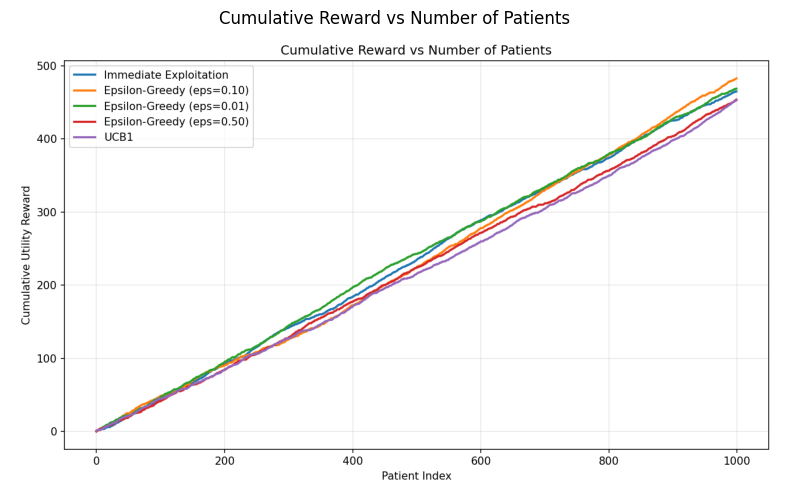

In [55]:
# Plot cumulative reward for all strategies

def plot_cumulative(results: Dict[str, BanditResult], output_path: str) -> None:
    """One line per strategy showing cumulative utility over 1000 patients. Saved to disk too."""
    plt.figure(figsize=(10, 6))

    for name, res in results.items():
        plt.plot(res.cumulative_reward, label=name, linewidth=2)

    plt.title("Cumulative Reward vs Number of Patients")
    plt.xlabel("Patient Index")
    plt.ylabel("Cumulative Utility Reward")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.close()


# Cumulative reward comparison plot
plot_cumulative(results, 'mab_cumulative_reward.png')
img = plt.imread('mab_cumulative_reward.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Cumulative Reward vs Number of Patients')
plt.show()


screenshot of virtual lab 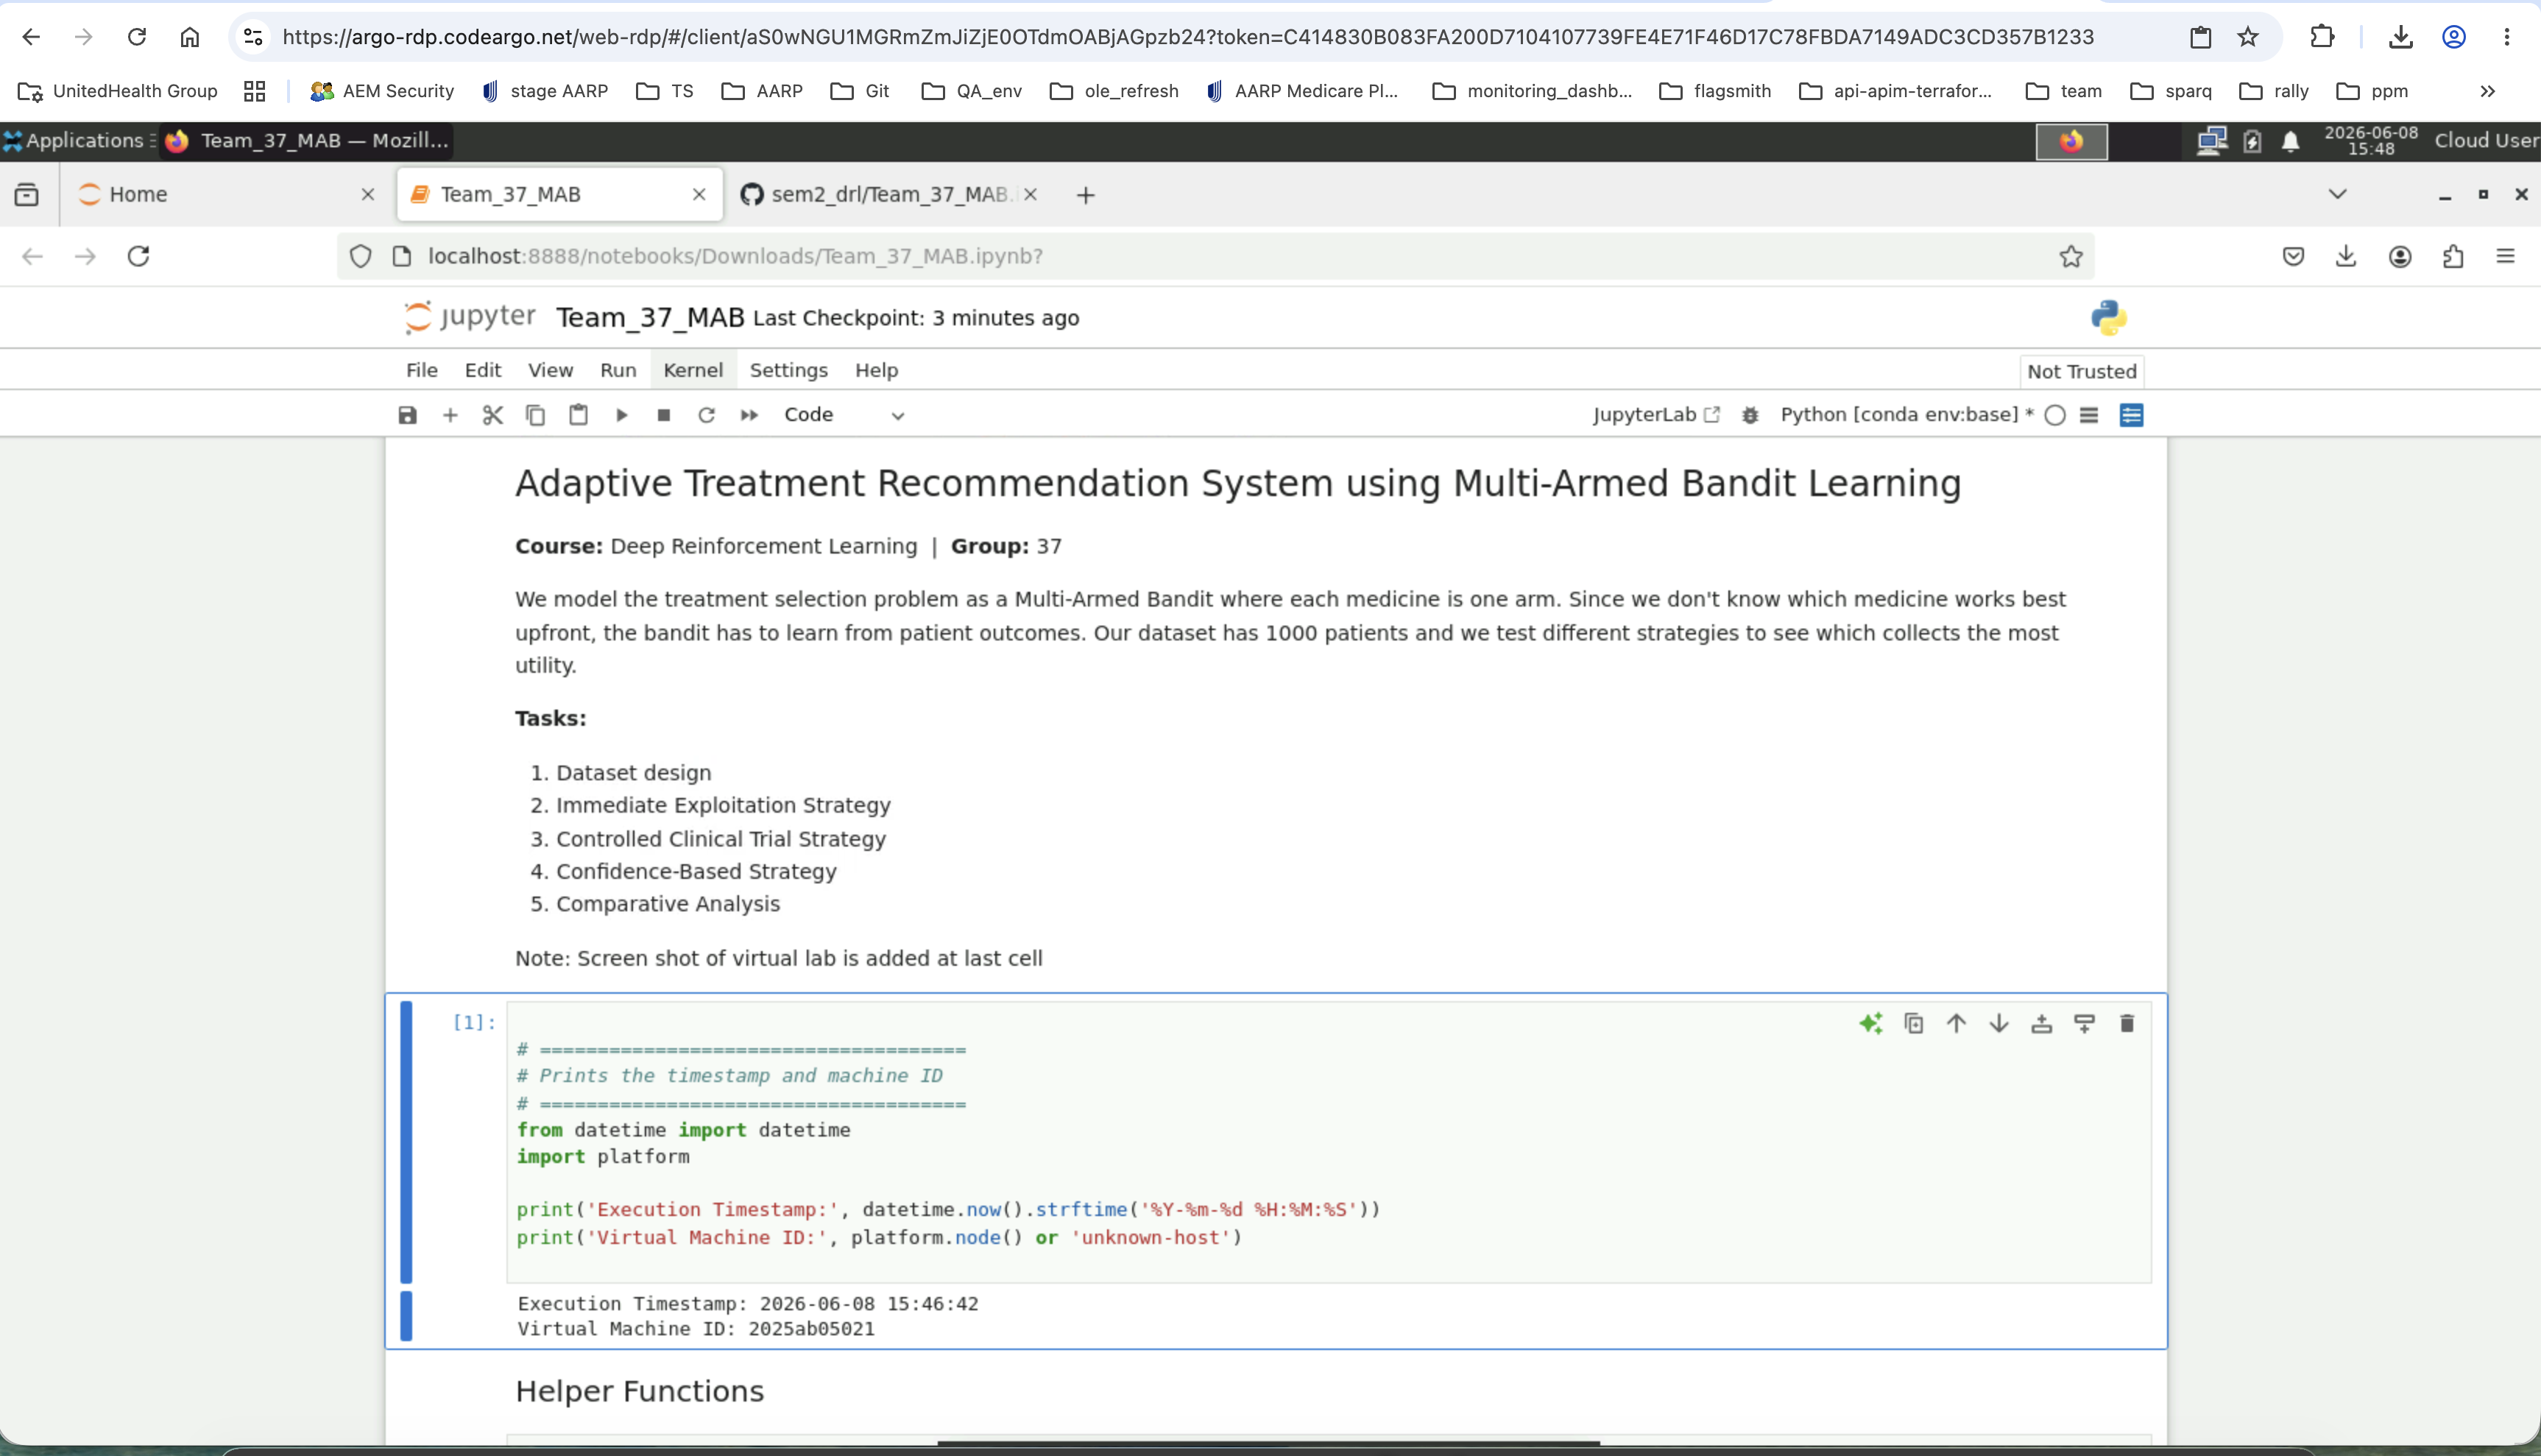